# Problema
#### Falha do motor
# Demonstrar o problema
#### Motor falhar antes da manutencao preditiva
# Ideias para superar o problema
#### Utilizar modelos de aprendizado de maquina para afirmar com exatidao quando dever ser feita  a manutencao afim de nao ter falhas no chao de fabrica, realizar num periodo que nao impacte na producao e que os trabalhadores estejam disnoniveis
# Descrever o ML
#### Acredito que seja um problema de regressao, pois queremos prever em quantos ciclos iremos precisar de manutencao
# Conclusao do ML
#### Usaremos modelos de arvores por generalizar muito bem em datasets com muito ruido e features

# Sobre o dataset
O dataset foi obtido atravez do bando de dados publicos da nasa
https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data

Se trata de dados simulados do motor CMAPSS onde foi usado o FD001 e representado por uma frota de 100 motores do mesmo tipo funcionamento. Cada motor opera ao longo do tempo ate apresentar a falha.
Os dados incluem informacoes sobre:<br>
- unit_number : Numero do motor
- settings : Configuracoes de operacoes
- time_cycles : Ciclo operacional
- sensors : medicao dos sensores.
- RUL : Vida util remanescente.

No conjunto de treinamento os motores operam ate a falha, ja no conjunto de teste, as series terminam antes da falha, o nosso objetivo e prever a vida util remanescente, ou seja quantos ciclos o motor ainda pode operar antes de falhar.

In [1]:
# Manipulacao de dados
import numpy as np
import pandas as pd

# Visualizacao de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Padronizacao de dados
from sklearn.preprocessing import StandardScaler

# Modelagem
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Avaliacao de metricas
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Definindo o nome das colunas para facilitar a indexacao e analise
index = ['unit_number', 'time_cycles']
settings = ['setting_1', 'setting_2', 'setting_3']
sensor = ['sensor_{}'.format(i) for i in range(1,22)]
cols = index + settings + sensor

Como o arquivo ja tras dados de treino, teste e target, definiremos cada dataset dessa forma.

In [3]:
train_df = pd.read_csv("./data/train_FD001.txt", sep="\s+", header=None)
train_df.columns = cols

test_df = pd.read_csv("./data/test_FD001.txt", sep="\s+", header=None)
test_df.columns = cols

y_test = pd.read_csv("./data/RUL_FD001.txt", header=None)
y_test.columns = ["RUL"]

Usaremos as funcoes info() e  describe() para analisar a presenca de dados faltantes, outliers e outras metricas como desvio padrao maxima e minima.

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sensor_15    20

In [5]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  13096 non-null  int64  
 1   time_cycles  13096 non-null  int64  
 2   setting_1    13096 non-null  float64
 3   setting_2    13096 non-null  float64
 4   setting_3    13096 non-null  float64
 5   sensor_1     13096 non-null  float64
 6   sensor_2     13096 non-null  float64
 7   sensor_3     13096 non-null  float64
 8   sensor_4     13096 non-null  float64
 9   sensor_5     13096 non-null  float64
 10  sensor_6     13096 non-null  float64
 11  sensor_7     13096 non-null  float64
 12  sensor_8     13096 non-null  float64
 13  sensor_9     13096 non-null  float64
 14  sensor_10    13096 non-null  float64
 15  sensor_11    13096 non-null  float64
 16  sensor_12    13096 non-null  float64
 17  sensor_13    13096 non-null  float64
 18  sensor_14    13096 non-null  float64
 19  sensor_15    13

In [6]:
train_df[index].describe()

,unit_number,time_cycles
count,20631.000000,20631.000000
mean,51.506568,108.807862
std,29.227633,68.880990
min,1.000000,1.000000
25%,26.000000,52.000000
50%,52.000000,104.000000
75%,77.000000,156.000000
max,100.000000,362.000000


In [7]:
train_df[settings].describe()

,setting_1,setting_2,setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


In [8]:
train_df[sensor].describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


Calculando o RUL de treino

In [9]:
# Ciclo maximo por motor
max_cycle = train_df.groupby("unit_number")["time_cycles"].max()
train_df["max_cycle"] = train_df["unit_number"].map(max_cycle)

# Calculando o valor do restante de vida util
train_df["RUL"] = train_df["max_cycle"] - train_df["time_cycles"] # Remaining Useful Life (RUL)
train_df[["unit_number", "time_cycles" ,"RUL"]]

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
...,...,...,...
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1


# Plotagem de graficos e tabelas

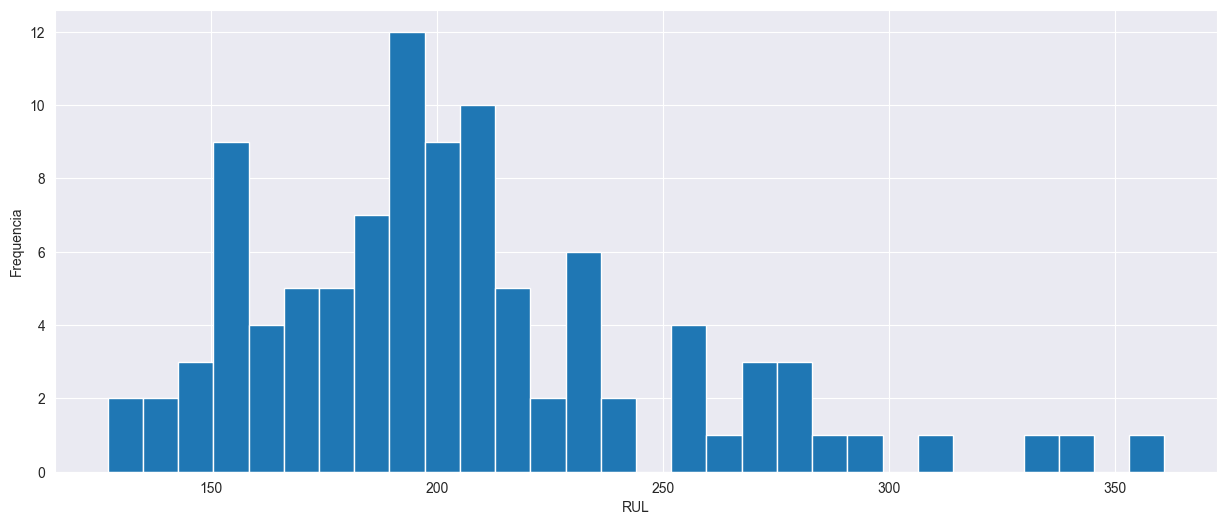

In [10]:
train_df_rul = train_df[['unit_number', 'RUL']].groupby('unit_number').max().reset_index()
train_df_rul['RUL'].hist(bins=30, figsize=(15,6))
plt.xlabel('RUL')
plt.ylabel('Frequencia')
plt.show()

Observando o grafico acima, podemos observador a variabilidade na vida util total das unidades, estando concentrada entre 180 e 210 ciclos aproximadamete.

<Axes: >

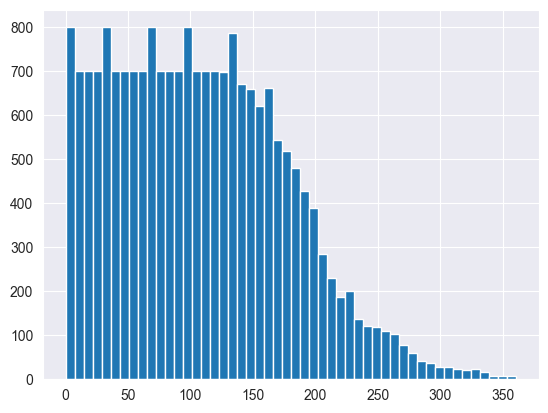

In [11]:
train_df["RUL"].hist(bins=50)

Nesse grafico podemos entender claramente o comportamento do modelo, ou seja a distribuicao de RULs em todos os ciclos. Podemos observar que tem uma concentracao ata de 0-150 e depois disso vai decaindo indicando desbalanceamento ao longo do tempo.


Como observamos que dados se encontram desbalanceados e queremos evitar viez de aprendizagem, Usaremos o metodo de clipagem.

In [12]:
RUL_CAP = 125
train_df["RUL"] = train_df["RUL"].clip(upper=RUL_CAP)

In [13]:
low_variance = train_df.std()[train_df.std() < 0.01].index
train_df.drop(columns=low_variance, inplace=True)

In [14]:
train_df

,unit_number,time_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,125
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,125
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,125
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,125
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,200,4
20627,100,197,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,200,3
20628,100,198,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,200,2
20629,100,199,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,200,1


Analisando sensores de maior correlacao com a TARGET

In [15]:
correlations = {}

for col in train_df.columns:
    if col.startswith("sensor"):
        corr = train_df[col].corr(train_df["RUL"])
        correlations[col] = corr

In [16]:
corr_df = (
    pd.Series(correlations)
    .abs()
    .sort_values(ascending=False)
)
corr_df

sensor_11    0.775230
sensor_4     0.757157
sensor_12    0.748870
sensor_7     0.733021
sensor_15    0.720858
sensor_21    0.707334
sensor_20    0.704626
sensor_17    0.680829
sensor_2     0.678458
sensor_3     0.655030
sensor_8     0.624568
sensor_13    0.624034
sensor_9     0.462151
sensor_14    0.369753
dtype: float64

In [17]:
main_sensors = corr_df.head(15).index.to_list()

Padronizando os dados

In [18]:
scaler = StandardScaler()
train_df[main_sensors] = scaler.fit_transform(train_df[main_sensors])
test_df[main_sensors] = scaler.transform(test_df[main_sensors])

Aqui apliquei a media movel para tentar suavizar os ruidos e melhorar a capacidade do modelo capturar padroes.

In [19]:
WINDOW = 20 # Com base em meus testes janela de 20 se adequou muito bem nesse cenario

for s in main_sensors:
    train_df[f"{s}_roll_mean"] = (
        train_df.groupby("unit_number")[s]
        .rolling(WINDOW)
        .mean()
        .reset_index(level=0, drop=True)
    )

    test_df[f"{s}_roll_mean"] = (
        test_df.groupby("unit_number")[s]
        .rolling(WINDOW)
        .mean()
        .reset_index(level=0, drop=True)
    )
train_df = train_df.dropna()

Comparando o ruido

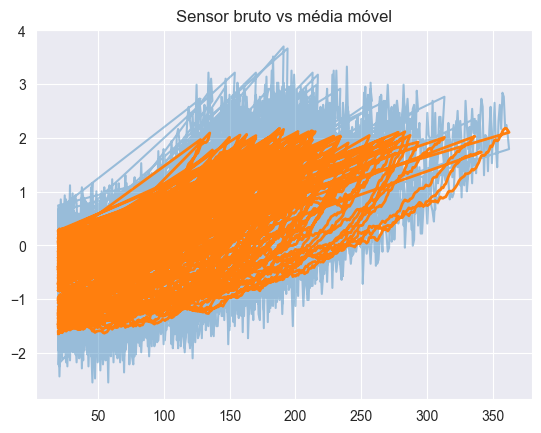

In [20]:
plt.plot(train_df["time_cycles"], train_df["sensor_11"], alpha=0.4)
plt.plot(train_df["time_cycles"], train_df["sensor_11_roll_mean"], linewidth=2)
plt.title("Sensor bruto vs média móvel")
plt.show()


Por meio dessa plotagem podemos constatar que obtivemos com sucesso uma diminuicao de ruido

In [21]:
corr = train_df.corr()["RUL"].abs().sort_values(ascending=False)
corr.head(10)

RUL                    1.000000
sensor_17_roll_mean    0.812605
sensor_3_roll_mean     0.808809
sensor_15_roll_mean    0.803370
sensor_20_roll_mean    0.799284
sensor_4_roll_mean     0.799233
sensor_21_roll_mean    0.799188
sensor_2_roll_mean     0.797835
sensor_11_roll_mean    0.792119
sensor_11              0.778552
Name: RUL, dtype: float64

E tambem uma melhora significativa na correlacao

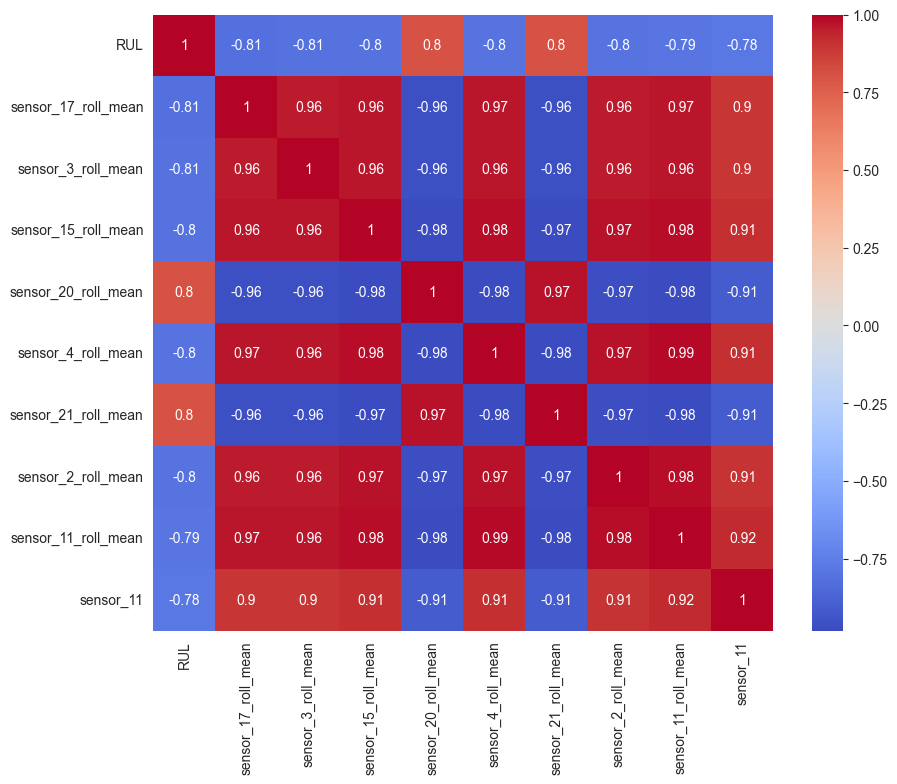

In [22]:
top10 = corr.head(10).index
plt.figure(figsize=[10,8])
sns.heatmap(train_df[top10].corr(), annot=True, cmap="coolwarm")
plt.show()
plt.show()


Agora calcularemos a varaicao do sensor de um ciclo para outro dentro da mesma maquina para qu eo modelo aprenda tambem com a velocidade de desgaste entre os ciclos

In [23]:
for s in main_sensors:
    train_df[f"{s}_diff"] = train_df.groupby("unit_number")[s].diff()
    test_df[f"{s}_diff"] = test_df.groupby("unit_number")[s].diff()

In [24]:
# Preparando meu treino e teste apenas com as features de maior importancia
feature_cols = (
    [f"{s}_roll_mean" for s in main_sensors] +
    [f"{s}_diff" for s in main_sensors]
)

# Treino e teste

In [25]:
feature_cols = [col for col in train_df.columns if "_roll_mean" in col or "_diff" in col]

X_train = train_df[feature_cols]
y_train = train_df["RUL"]

In [26]:
test_last = test_df.groupby("unit_number").last().reset_index()
X_test = test_last[feature_cols].fillna(0)

# Primeiro modelo - Random Forest

Naturalmente escolhi esse modelo por lidar muito bem com muitas features, reduz a probabilidade de overfiting e e robusto a ruido

In [27]:
# Todos os parametros foram testados para buscar melhor performace do modelo
model_RF = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    max_features="log2",
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=1,
    bootstrap=True,
)

model_RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [28]:
y_pred_RF = model_RF.predict(X_test)

In [29]:
r2 = r2_score(y_test["RUL"], y_pred_RF)
rmse = np.sqrt(mean_squared_error(y_test["RUL"], y_pred_RF))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.7282892008753874
RMSE: 21.661235398748612


Podemos constatar que esse modelo teve um bom desenpenho ao observar as metricas, porem ainda podemos melhorar.

Um R2 de 72.8 indica que o modelo explica quase 73% da variabilidade da nossa target <br>
O RMSE de 21.66  indica que ele esta prevendo 21 unidades a mais ou amenos com o valor real

# Segundo modelo - Extra Trees Regressor

Como ExtraTrees tambem e um modelo baseado em arvores, essa foi minha segunda escolha sua capacidade de capturar relações não lineares e interações entre sensores sao levemente superiores ao randomforest, além de serer robusta a ruído e nao exigir padronizacao dos dados.

In [53]:
model_ETR = ExtraTreesRegressor(
    random_state=42,
    n_estimators =  1000,
    criterion = 'squared_error',
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf =  1,
    max_features = 'log2',
    bootstrap = False
)

model_ETR.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is 

In [54]:
y_pred_ETR = model_ETR.predict(X_test)

In [55]:
r2 = r2_score(y_test["RUL"], y_pred_ETR)
rmse = np.sqrt(mean_squared_error(y_test["RUL"], y_pred_ETR))

print("R2:", r2)
print("RMSE:", rmse)


R2: 0.7422942988630987
RMSE: 21.095595299493212


Ja tivemos uma melhora levemente significativa do nosso R2

# Terceiro modelo - XGBoost

Claro, mantendo a mesma linha de racicionio anterior, irei escolher outro modelo baseado em arvore

In [30]:
model_XGB = XGBRegressor(
    n_estimators=115,
    learning_rate=0.029,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.9,
    random_state=42,
    reg_alpha=2,
    reg_lambda=1,
)
model_XGB.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [31]:
y_pred_XGB = model_XGB.predict(X_test)

In [32]:
r2 = r2_score(y_test, y_pred_XGB)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_XGB))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.7406401634216309
RMSE: 21.163190100605696


Tivemos um leve downgrade, mas sera superado fazendo a melhoria dos hiperparametros e utilizando o crossvalidation

## Melhoramento de hiperparametros e otimizacao com Cross Validation

Aqui foi aplicado o gridsearch algumas vezes ate encontrar esses parametros (optei por fazer dessa forma para nao ficar muito extenso), junto a ele utilizeo crossvalidation de 5 folds para otimizacao dos hiperparametros

In [38]:
param_grid = {
    'n_estimators': [110],
    'learning_rate': [0.05],
    'max_depth': [3],
    'subsample': [0.85],
    'colsample_bytree': [0.86],
    'reg_alpha': [3],
    'reg_lambda': [1]
}

model = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring=scoring,
    refit='rmse',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Best RMSE:", -grid.cv_results_['mean_test_rmse'][grid.best_index_])
print("Best R2:", grid.cv_results_['mean_test_r2'][grid.best_index_])
print("Best MAE:", -grid.cv_results_['mean_test_mae'][grid.best_index_])


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best RMSE: 20.060335159301758
Best R2: 0.7673474669456481
Best MAE: 15.285201263427734


O modelo otimizado via GridSearch apresentou RMSE de 20,06, MAE de 15,29 e R2 de 0,767 na validacao cruzada. Os resultados indicam boa capacidade preditiva, com erro médio absoluto aproximado de 15 unidades e explicacao de 76,7% da variabilidade da variável alvo. Nao tem indicacao grave de instabilidade e as metricas estao coerentes entre si.

# Metricas para melhorias

Constatando a presenca de overfiting

In [43]:
score_train = grid.score(X_train, y_train)
score_test = grid.score(X_test, y_test)
print("Score Train:", score_train)
print("Score teste:", score_test)

Score Train: -17.977312088012695
Score teste: -21.301742553710938


Nao tivemos uma diferenca tao grande de treino para teste, mas podemos aferir uma presenca bem leve de overfiting, contudo, esta aceitavel, podendo melhorar e claro.

Cosntatando quais variaveis tem maior peso

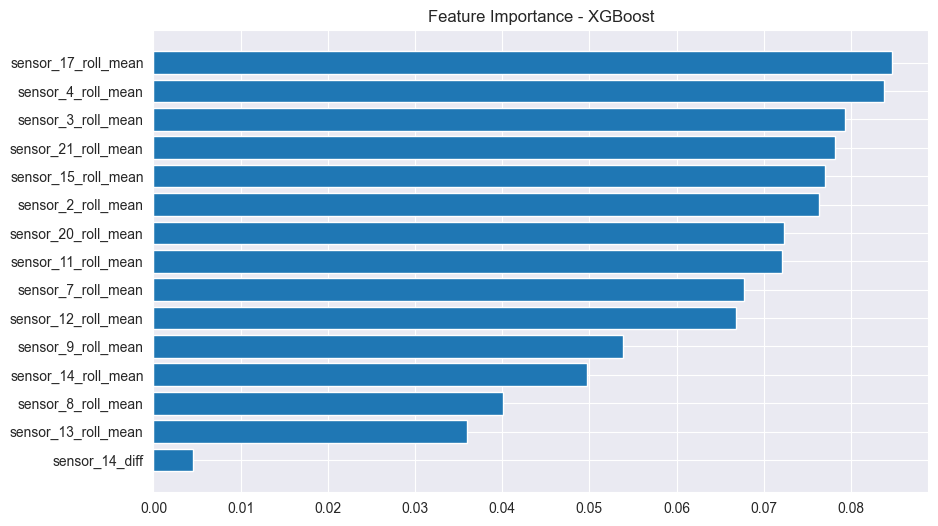

,feature,importance
7,sensor_17_roll_mean,0.084671
1,sensor_4_roll_mean,0.083854
9,sensor_3_roll_mean,0.079303
5,sensor_21_roll_mean,0.078218
4,sensor_15_roll_mean,0.076990
8,sensor_2_roll_mean,0.076308
6,sensor_20_roll_mean,0.072378
0,sensor_11_roll_mean,0.072089
3,sensor_7_roll_mean,0.067797
2,sensor_12_roll_mean,0.066870


In [95]:
importances = model_ETR.feature_importances_

# Criando dataframe organizado
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top_importances = feat_imp.head(15)
# Visualizacao
plt.figure(figsize=(10,6))
plt.barh(top_importances['feature'], top_importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()

feat_imp.head(10)

Por fim, melhorando a clipagem, ajustando metricas e a features_sensor, podemos chegar possivelmente a resultados melhores, contudo e limitado, pois nosso dataset apresenta muito ruido.